# Controlling the PID to do the NPG ramps
This cell sets up the serial communication with the PID controller and initializes the SQLite database where temperature readings are regularly stored. At the same time, it starts a loop that will do the NPG annealings with the parameters of 1st August 2024.

Run the code after the DP-DBBA depositon. The code will:
- Wait 5 min, in the supposed 200ºC temperature.
- Ramp the temperature to 350ºC.
- Upon reaching 350ºC, wait 15 min.
- Ramp the temperature to 550ºC.
- Upon reaching 550ºC, wait 40 min.
- Ramp the temperature to 0ºC.
- Wait 10 min and stop recording the temperature. Code shuts down.

In [1]:
import serial
import time
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

# Configure the serial port (adjust as needed)
ser = serial.Serial(
    port='COM9',        # Your COM port
    baudrate=9600,      # Baud rate
    bytesize=8,         # Data bits
    parity=serial.PARITY_NONE,  # Parity
    stopbits=1,         # Stop bits
    timeout=1)          # Read timeout

# Function to send a command to the PID controller and read the response
def send_command(command):
    ser.write(command.encode())
    time.sleep(0.5)  # Wait for a response
    response = ser.read(100)  # Read response (adjust the size as needed)
    return response

# Function to calculate BCC
def calculate_bcc(message):
    bcc = 0
    for char in message:
        bcc ^= ord(char)
    return chr(bcc)

# Function to read temperature from the device
def read_temperature():
    send_command(chr(4))  # EOT
    identifier_PV = "M1"
    command_read_PV = "00" + identifier_PV + chr(5)  # ENQ
    response = send_command(command_read_PV)
    response_str = response.decode(errors='ignore')
    temperature = response_str[6:9]
    print(f"Read_PV Response: {response_str}")
    print(f"Cu disk temperature: {temperature}ºC")
    return float(temperature)

# Function to set a new temperature goal
def set_temperature_goal(goal_temperature):
    send_command(chr(4))  # EOT
    identifier_SV = "S1"
    set_temperature = "0" + goal_temperature + ".0"
    message_body = "00" + chr(2) + identifier_SV + set_temperature + chr(3)
    bcc = calculate_bcc(identifier_SV + set_temperature + chr(3))
    full_message = message_body + bcc
    response = send_command(full_message)
    response_str = response.decode(errors='ignore')
    print(f"Set Temperature Response: {response_str}")
    if response == b'\x06':
        print("Successfully changed SV1")

# Initialize SQLite database
custom_name = input("Enter a custom name for the database: ")
current_date = datetime.now().strftime('%Y-%m-%d')
db_name = f"{custom_name}___PID_temperature_curve___{current_date}.db"

conn = sqlite3.connect(db_name)
c = conn.cursor()
c.execute('''CREATE TABLE IF NOT EXISTS temperatures
             (timestamp TEXT, temperature REAL)''')
conn.commit()

# Function to read temperature and save to database
def read_and_store_temperature():
    temperature = read_temperature()
    timestamp = datetime.now().isoformat()
    c.execute("INSERT INTO temperatures (timestamp, temperature) VALUES (?, ?)",
              (timestamp, temperature))
    conn.commit()

# Function to plot temperature data
def plot_temperature_data():
    c.execute("SELECT timestamp, temperature FROM temperatures")
    data = c.fetchall()
    
    times = [datetime.fromisoformat(row[0]) for row in data]
    temperatures = [row[1] for row in data]
    
    plt.plot(times, temperatures, marker='o')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.title('Temperature over Time')
    plt.gcf().autofmt_xdate()
    plt.show()

# Main function to control the temperature and record data
def main(): #temperature1=350, temperature2=550, temperature3=0
    print("--- Start NPG ramps ---")
    # Initial state variables
    GNR_temp_reached = False
    GNR_growth_completed = False
    NPG_temp_reached = False
    NPG_growth_completed = False

    try:
        # Initial wait time before setting the first temperature goal
        time.sleep(5 * 60)  # 5 minutes
        set_temperature_goal("350")

        # Recording and monitoring loop
        while True:
            temperature = read_temperature()
            read_and_store_temperature()

            if temperature >= 349 and not GNR_temp_reached:
                GNR_temp_reached = True
                print("Reached 349°C, starting 15-minute timer...")
                time.sleep(15 * 60)  # 15 minutes
                set_temperature_goal("550")
                GNR_growth_completed = True

            if temperature >= 549 and not NPG_temp_reached and GNR_growth_completed:
                NPG_temp_reached = True
                print("Reached 549°C, starting 40-minute timer...")
                time.sleep(40 * 60)  # 40 minutes
                set_temperature_goal("000")
                NPG_growth_completed = True

            if NPG_growth_completed:
                print("Cooling down to 0°C...")
                time.sleep(10 * 60)  # 10 minutes cooldown time
                break

            time.sleep(10)  # Sleep time between temperature readings

    except KeyboardInterrupt:
        print("Stopping temperature recording.")
        #Can interrupt the code manually in Jupyter notebooks by pressing I+I fast with the cell selected. Same in a windows terminal by pressing Ctrl+C.
    finally:
        print("Stopping the NPG ramps control code. Closing database and serial.")
        conn.close()
        ser.close()

if __name__ == "__main__":
    main()

Enter a custom name for the database: SC53
--- Start NPG ramps ---
Set Temperature Response: 
Successfully changed SV1
Read_PV Response: M1000200}
Cu disk temperature: 200ºC
Read_PV Response: M1000200}
Cu disk temperature: 200ºC
Read_PV Response: M1000201|
Cu disk temperature: 201ºC
Read_PV Response: M1000202
Cu disk temperature: 202ºC
Read_PV Response: M1000209t
Cu disk temperature: 209ºC
Read_PV Response: M1000211}
Cu disk temperature: 211ºC
Read_PV Response: M1000219u
Cu disk temperature: 219ºC
Read_PV Response: M1000221~
Cu disk temperature: 221ºC
Read_PV Response: M1000232|
Cu disk temperature: 232ºC
Read_PV Response: M1000234z
Cu disk temperature: 234ºC
Read_PV Response: M1000244}
Cu disk temperature: 244ºC
Read_PV Response: M1000247~
Cu disk temperature: 247ºC
Read_PV Response: M1000257
Cu disk temperature: 257ºC
Read_PV Response: M1000260{
Cu disk temperature: 260ºC
Read_PV Response: M1000270z
Cu disk temperature: 270ºC
Read_PV Response: M10002

Set Temperature Response: 
Successfully changed SV1
Cooling down to 0°C...
Stopping the NPG ramps control code. Closing database and serial.


# Plotting the recorded temperature
This cell makes a plot of the recorded temperatures during the NPG annealings.

NPG_S53


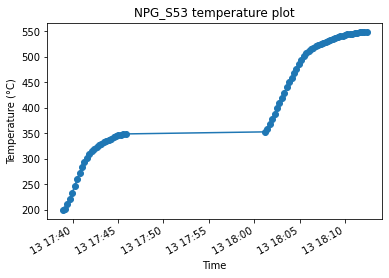

In [3]:
import serial
import time
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

custom_name = 'NPG_S53' #it is used for the plot title, change it if wanted
print(custom_name)


# Function to plot temperature data
def plot_temperature_data(conn):
    c = conn.cursor()
    c.execute("SELECT timestamp, temperature FROM temperatures")
    data = c.fetchall()
    
    times = [datetime.fromisoformat(row[0]) for row in data]
    temperatures = [row[1] for row in data]
    
    plt.plot(times, temperatures, marker='o')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.title(f'{custom_name} temperature plot')
    plt.gcf().autofmt_xdate()
    plt.show()

# Reconnect to the database
conn = sqlite3.connect(db_name)
# Plot the temperature data
plot_temperature_data(conn)
# Close the connection after plotting
conn.close()